# Linear Regression with scikit-learn

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
# SGDRegressor is a scikit-learn model for linear regression with SGD.
from sklearn.preprocessing import StandardScaler
# class for zscore-normalization(makes Mean ≈ 0 and S.D ≈ 1)

## Load data

In [26]:
def load_data(path):
    data = np.loadtxt(path, delimiter=',', skiprows=1)
    # skiprows=n will skip first 'n' rows
    X = data[:,:4]
    y = data[:,4]

    return X,y

In [27]:
path = r"C:\Machine Learning\Coursera\Supervised ML (Regression and Classification)\02_Regression_Multiple_Variable\houses.txt"

X_train, y_train = load_data(path)
X_features = ['size(sqft)','bedrooms','floors','age']

## Scale/Normalize the training data

In [28]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)
# here fit is calculating mean and sigma
# transform convert row data to normalized

print(f"peak to peak range by column in raw: {np.ptp(X_train,axis=0)}")
print(f"peak to peak range by column in normalized: {np.ptp(X_norm,axis=0)}")

peak to peak range by column in raw: [2.406e+03 4.000e+00 1.000e+00 9.500e+01]
peak to peak range by column in normalized: [5.8452591  6.13529646 2.05626214 3.68533012]


## Create and Fit the regression model

In [29]:
sgdr = SGDRegressor(max_iter=1000)
# Allows up to 1000 passes over the training data to minimize prediction error (cost).
sgdr.fit(X_norm, y_train)
print(sgdr)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

SGDRegressor()
number of iterations completed: 128, number of weight updates: 12673.0


## View Parameters

In [30]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters: {w_norm,b_norm}")

model parameters: (array([110.19374465, -21.11376239, -32.52106037, -38.02647432]), array([363.13792646]))


## Make Predictions

In [31]:
# by np.dot()
y_pred = np.dot(X_norm,w_norm) + b_norm

# by @
y_pred_mtx = X_norm @ w_norm + b_norm

# by sgdr.predict()
y_pred_sgdr = sgdr.predict(X_norm)

print(
    f"Predictions match: "
    f"{np.allclose(y_pred, y_pred_mtx) and np.allclose(y_pred_mtx, y_pred_sgdr)}"
)
# np.allclose return true when values have tiny decimal difference

print(f"Prediction on training set:\n{y_pred[:4]}" )
print(f"Target values \n{y_train[:4]}")

Predictions match: True
Prediction on training set:
[295.17700395 485.83799765 389.52733386 492.00083941]
Target values 
[300.  509.8 394.  540. ]


## Plot Results

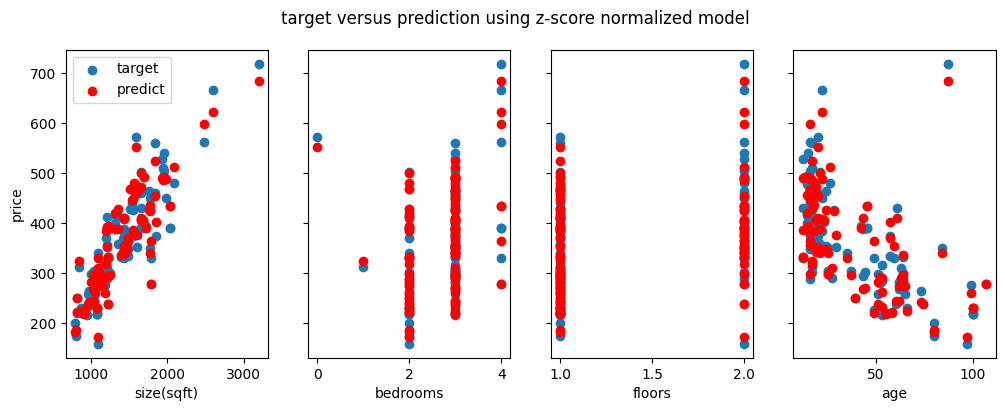

In [32]:
fig, ax = plt.subplots(1,4, figsize=(12,4),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train,label='target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:,i],y_pred,color='r',label='predict')
ax[0].set_ylabel('price')
ax[0].legend()
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()

## 